### Unsupervised Learning Using K-Means Clustering

## Steps
1. Select K
2. Initialize Controls
(repeat)
3. Distributte the data points into different clusters
4. Update the controls
(repeat)
5. Finish

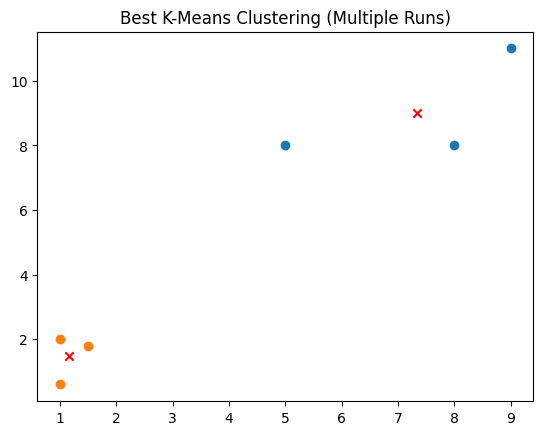

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def kmeans(X, k, max_iters=100, tol=1e-4):
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]

    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else centroids[i]
            for i in range(k)
        ])

        if np.linalg.norm(new_centroids - centroids) < tol:
            break

        centroids = new_centroids

    # Compute inertia (cost)
    inertia = np.sum((X - centroids[labels])**2)

    return centroids, labels, inertia


# Sample dataset
X = np.array([
    [1, 2], [1.5, 1.8], [5, 8],
    [8, 8], [1, 0.6], [9, 11],
])


k = 2
best_inertia = float('inf')
best_centroids = None
best_labels = None

runs = 10
count = 0

while count < runs:
    centroids, labels, inertia = kmeans(X, k)

    if inertia < best_inertia:
        best_inertia = inertia
        best_centroids = centroids
        best_labels = labels

    count += 1


# Plot

for i in range(2):
    plt.scatter(X[labels == i][:, 0], X[labels == i][:, 1])

plt.scatter(best_centroids[:, 0], best_centroids[:, 1], c='red', marker='x')
plt.title("Best K-Means Clustering (Multiple Runs)")
plt.show()

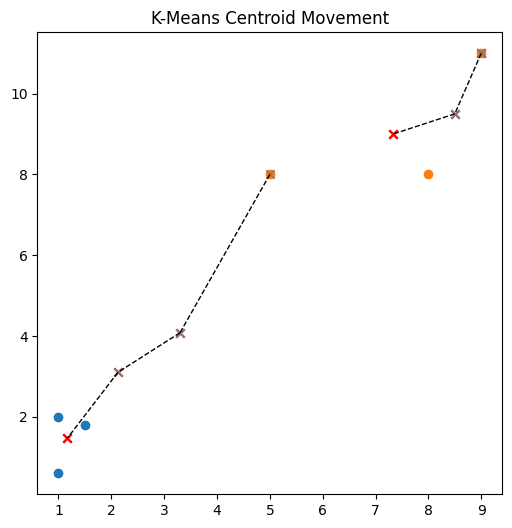

In [25]:
import matplotlib.pyplot as plt
import numpy as np


def kmeans_with_history(X, k, max_iters=100, tol=1e-4):
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]

    history = [centroids.copy()]

    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else centroids[i]
            for i in range(k)
        ])

        history.append(new_centroids.copy())

        if np.linalg.norm(new_centroids - centroids) < tol:
            break

        centroids = new_centroids

    return centroids, labels, history


# Sample dataset
X = np.array([
    [1, 2], [1.5, 1.8], [5, 8],
    [8, 8], [1, 0.6], [9, 11]
])

centroids, labels, history = kmeans_with_history(X, k=2)

# Plot evolution
plt.figure(figsize=(6, 6))

for i in range(2):
    plt.scatter(X[labels == i][:, 0], X[labels == i][:, 1])

# Plot centroid movement
for i in range(len(history) - 1):
    c_old = history[i]
    c_new = history[i + 1]

    plt.scatter(c_old[:, 0], c_old[:, 1], c='gray', marker='x')
    plt.scatter(c_new[:, 0], c_new[:, 1], c='red', marker='x')

    # Draw movement lines
    for j in range(len(c_old)):
        plt.plot(
            [c_old[j, 0], c_new[j, 0]],
            [c_old[j, 1], c_new[j, 1]],
            'k--', linewidth=1
        )

plt.title("K-Means Centroid Movement")
plt.show()

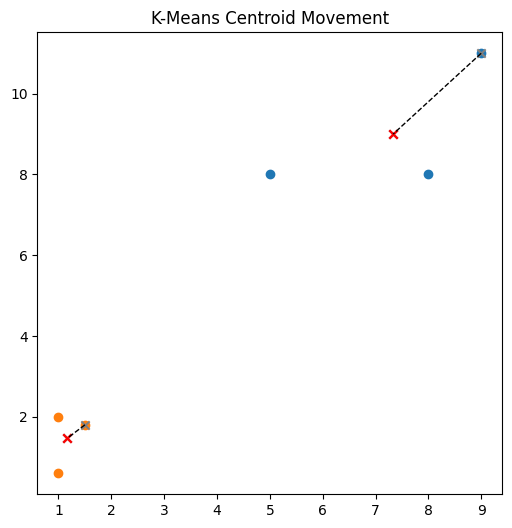

In [26]:
import matplotlib.pyplot as plt
import numpy as np


def kmeans_with_history(X, k, tol=1e-4):
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]

    history = [centroids.copy()]

    while True:
        # Assign clusters
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else centroids[i]
            for i in range(k)
        ])

        history.append(new_centroids.copy())

        # Check convergence
        if np.linalg.norm(new_centroids - centroids) < tol:
            break

        centroids = new_centroids

    return centroids, labels, history


# Sample dataset
X = np.array([
    [1, 2], [1.5, 1.8], [5, 8],
    [8, 8], [1, 0.6], [9, 11]
])

centroids, labels, history = kmeans_with_history(X, k=2)

# Plot evolution
plt.figure(figsize=(6, 6))

for i in range(2):
    plt.scatter(X[labels == i][:, 0], X[labels == i][:, 1])

# Plot centroid movement
for i in range(len(history) - 1):
    c_old = history[i]
    c_new = history[i + 1]

    plt.scatter(c_old[:, 0], c_old[:, 1], c='gray', marker='x')
    plt.scatter(c_new[:, 0], c_new[:, 1], c='red', marker='x')

    for j in range(len(c_old)):
        plt.plot(
            [c_old[j, 0], c_new[j, 0]],
            [c_old[j, 1], c_new[j, 1]],
            'k--', linewidth=1
        )

plt.title("K-Means Centroid Movement")
plt.show()

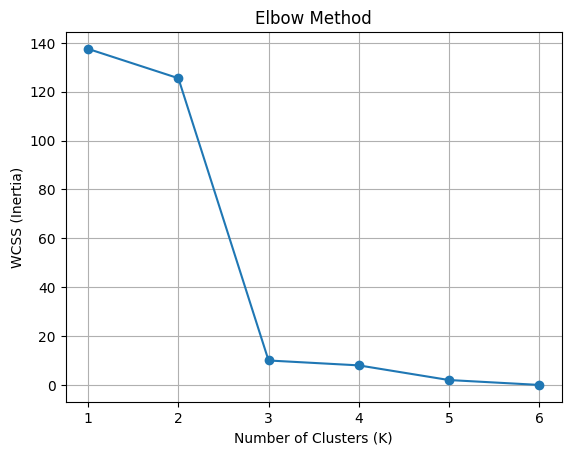

Centroids:
 [[5.5 1. ]
 [5.5 4. ]]
Labels:
 [0 1 0 0 1 0]


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def kmeans(X, k, max_iters=100, tol=1e-4):
    # Step 1: Initialize centroids randomly
    np.random.seed(42)
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]

    for _ in range(max_iters):
        # Step 2: Assign clusters (compute distances)
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Step 3: Update centroids
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else centroids[i]
            for i in range(k)
        ])

        # Step 4: Check convergence
        if np.all(np.linalg.norm(new_centroids - centroids, axis=1) < tol):
            break

        centroids = new_centroids

    return centroids, labels



def compute_wcss(X, centroids, labels):
    wcss = 0
    for i, centroid in enumerate(centroids):
        cluster_points = X[labels == i]
        wcss += np.sum((cluster_points - centroid) ** 2)
    return wcss



def elbow_method(X, max_k=10):
    k_values = range(1, max_k + 1)
    wcss_values = []

    for k in k_values:
        centroids, labels = kmeans(X, k)
        wcss = compute_wcss(X, centroids, labels)
        wcss_values.append(wcss)

    # Plot Elbow Curve
    plt.figure()
    plt.plot(k_values, wcss_values, marker='o')
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("WCSS (Inertia)")
    plt.title("Elbow Method")
    plt.xticks(k_values)
    plt.grid()
    plt.show()

    return k_values, wcss_values


if __name__ == "__main__":
    X = np.array([
        [1, 2], [1, 4], [1, 0],
        [10, 2], [10, 4], [10, 0]
    ])

    # Run Elbow Method
    elbow_method(X, max_k=6)

    # Run final KMeans with chosen K
    k = 2
    centroids, labels = kmeans(X, k)

    print("Centroids:\n", centroids)
    print("Labels:\n", labels)